<a href="https://colab.research.google.com/github/salomesanchez160/Analitica-de-Negocios/blob/main/Parcial1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##***Reto Parcial I – Analítica de Negocios***

Una entidad del sector Salud quiere implementar un modelo para la clasificación
de pacientes que poseen diabetes en función de sus variables de salud. Las variables consideradas son:

* Pregnancies: Número de embarazos de la paciente.
* Glucose: Concentración de glucosa en plasma a las 2 horas (mg/dL).
* BloodPressure: Presión arterial diastólica (mm Hg).
* SkinThickness: Grosor del pliegue cutáneo del tríceps (mm).
* Insulin: Insulina sérica de 2 horas (mu U/ml).
* BMI: Índice de masa corporal (peso en kg / altura en m²).
* DiabetesPedigreeFunction: Función de pedigrí de diabetes (carga genética).
* Age: Edad del paciente en años.
* Outcome: Variable objetivo — 0: Sin diabetes, 1: Con diabetes.

0. Se procede con la carga de librerías de trabajo

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, export_graphviz, export_text
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix
from pydotplus import graph_from_dot_data

1. Se cargan los datos de trabajo y se realiza el análisis exploratorio

In [ ]:
nxl = '/content/diabetes.csv'
XDB = pd.read_csv(nxl)
XDB.head(10)

#Primeras filas de la base
display (XDB.head(10))

#Número de observaciones y variables
print("Número de filas (pacientes):", XDB.shape[0])
print("Número de columnas (variables):", XDB.shape[1])

#Tipo de datos de cada variable
print(XDB.dtypes)

#Distribución de la variable objetivo
print("Sin diabetes (0):", (XDB['Outcome']==0).sum())
print("Con diabetes (1):", (XDB['Outcome']==1).sum())

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


Número de filas (pacientes): 768
Número de columnas (variables): 9
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object
Sin diabetes (0): 500
Con diabetes (1): 268


***Análisis Exploratorio de Resultados***

La base de datos cuenta con 768 observaciones y 9 variables (8 predictoras + 1 objetivo).
Todas las variables son de tipo numérico: 6 enteras (int64) y 3 de punto flotante (float64).
De los 768 pacientes, 500 (65.1%) no presentan diabetes (Outcome=0) y 268 (34.9%)
sí la presentan (Outcome=1), lo que indica un desbalance moderado en la variable objetivo.

2. Análisis de Correlación

Outcome                     1.000000
Glucose                     0.466581
BMI                         0.292695
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
Insulin                     0.130548
SkinThickness               0.074752
BloodPressure               0.065068
Name: Outcome, dtype: float64


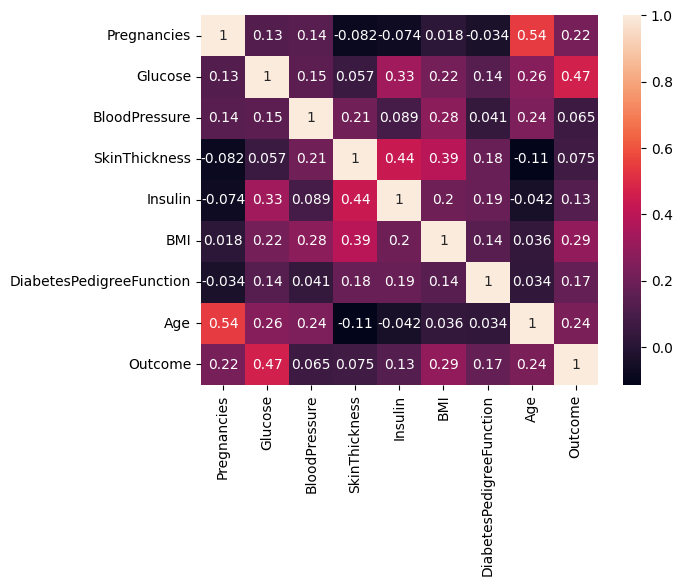

In [ ]:
#Determinamos la correlación entre las variables
XDB2 = XDB[['Pregnancies','Glucose','BloodPressure','SkinThickness',
             'Insulin','BMI','DiabetesPedigreeFunction','Age','Outcome']]
sns.heatmap(XDB2.corr(), annot=True)

#Correlación de cada variable con la variable de salida Outcome
print(XDB2.corr()['Outcome'].sort_values(ascending=False))

###***Análisis de Resultados – Correlación***

Del heatmap se puede observar que las variables con mayor correlación entre sí son
SkinThickness con BMI (0.39) e Insulin con Glucose (0.33), indicando que a mayor
grosor del pliegue cutáneo, mayor es el índice de masa corporal, y que la glucosa
está relacionada con los niveles de insulina del paciente.

Con respecto a la variable de salida (Outcome), la variable con mayor correlación
es Glucose (0.47), siendo el predictor individual más relevante para la detección
de diabetes. Le siguen en importancia BMI (0.29), Age (0.24) y Pregnancies (0.22).
Las variables BloodPressure (0.07) y SkinThickness (0.07) presentan la correlación
más baja con Outcome, lo que sugiere un menor poder predictivo individual.

In [ ]:
#Selección de variables de entrada y salida
XD = XDB[['Pregnancies','Glucose','BloodPressure','SkinThickness',
           'Insulin','BMI','DiabetesPedigreeFunction','Age']]
XDB.head (10)
yd = XDB['Outcome']
yd.head ()

,Outcome
0,1
1,0
2,1
3,0
4,1


3. Se procede con la implementación del Modelo Naive Bayes

In [ ]:
mnb = GaussianNB()
mnb.fit(XD, yd) #El modelo busca la mejor relación entre la entrada y la salida

#Mostramos las medias de las variables por clase
u = mnb.theta_
sigma = mnb.var_; sigma = np.sqrt(sigma)
print("Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age")
print("Medias por clase (0: Sin Diabetes | 1: Con Diabetes):")
print(u)
print("Las desviaciones son:")
print(sigma)

#Límites inferiores (media - 1 desviación estándar)
print("Límites inferiores:")
print(u - sigma)

#Límites superiores (media + 1 desviación estándar)
print("Límites superiores:")
print(u + sigma)

#Evaluación del modelo con la matriz de confusión
ydp = mnb.predict(XD) #Esto es lo que el modelo aprende
cm = confusion_matrix(yd, ydp)
print(cm)
VN=cm[0,0]; FP=cm[0,1]; FN=cm[1,0]; VP=cm[1,1]; TDatos=len(XDB)

#1. Exactitud: Funcionamiento general del modelo
Ex = (VP+VN)/TDatos
print("Exactitud: ", Ex)

#2. Tasa de error: % Fallos del Modelo
TEr = (FP+FN)/TDatos
print("Tasa de Error: ", TEr)

#3. Sensibilidad: Cómo se comportó con respecto a los positivos solamente
Se = VP/(VP+FN)
print("Sensibilidad: ", Se)

#4. Especificidad: Cómo se comporta pronosticando negativos
Es = VN/(VN+FP)
print("Especificidad: ", Es)

#5. Precisión: Cómo se comporta el modelo frente a los positivos solamente
Pr = VP/(VP+FP)
print("Precisión: ", Pr)

#6. Predicción Negativa: Cómo funciona el modelo pronosticando sin diabetes
PrN = VN/(VN+FN)
print("Predicción Negativa: ", PrN)

Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age
Medias por clase (0: Sin Diabetes | 1: Con Diabetes):
[[  3.298      109.98        68.184       19.664       68.792
   30.3042       0.429734    31.19      ]
 [  4.86567164 141.25746269  70.82462687  22.1641791  100.3358209
   35.14253731   0.5505      37.06716418]]
Las desviaciones son:
[[  3.01416809  26.11504573  18.04500366  14.87505016  98.76637459
    7.68216217   0.29880826  11.65598187]
 [  3.73425437  31.87997773  21.45167782  17.64669641 138.43013459
    7.24940518   0.37167699  10.94777197]]
Límites inferiores:
[[  0.28383191  83.86495427  50.13899634   4.78894984 -29.97437459
   22.62203783   0.13092574  19.53401813]
 [  1.13141727 109.37748496  49.37294904   4.51748269 -38.0943137
   27.89313213   0.17882301  26.11939221]]
Límites superiores:
[[  6.31216809 136.09504573  86.22900366  34.53905016 167.55837459
   37.98636217   0.72854226  42.84598187]
 [  8.59992601 173.13744041  

###***Análisis de Resultados – Naive Bayes***

De los resultados del modelo Naive Bayes se puede observar que los pacientes CON
diabetes presentan valores medios consistentemente más altos en todas las variables,
siendo las diferencias más notorias en Glucose (141.26 vs 109.98), BMI (35.14 vs 30.30),
Age (37.07 vs 31.19) e Insulin (100.34 vs 68.79). Esto indica que los pacientes
con diabetes tienden a ser de mayor edad, con mayor glucosa y mayor índice de masa corporal.

Con respecto a los límites, el grupo CON diabetes presenta un límite inferior de Glucose
de 109.38, valor que casi coincide con la media del grupo SIN diabetes (109.98), lo que
refuerza a la glucosa como el discriminador más poderoso entre los dos grupos.
Un paciente con Glucose superior a 109 ya se aproxima al perfil de riesgo del grupo con diabetes.

El modelo alcanzó una exactitud del 76.3%, superando el umbral del 75%. La especificidad
(84.2%) indica buen comportamiento identificando pacientes sanos. La sensibilidad (61.6%)
representa una oportunidad de mejora en la detección de casos positivos de diabetes,
aspecto crítico desde el punto de vista clínico y de salud pública.

4. Se procede con la implementación del Árbol de Decisión

In [ ]:
mar = DecisionTreeClassifier(criterion='gini', max_depth=4)
mar.fit(XD, yd) #Aquí el modelo busca relación entrada-salida

#¿Y qué fue lo que hizo el modelo?
ydp = mar.predict(XD) #Esto es lo que pronostica el modelo

#Se construye la matriz de confusión
cm = confusion_matrix(yd, ydp)
display(cm)
VN=cm[0,0]; FP=cm[0,1]; FN=cm[1,0]; VP=cm[1,1]

#Métricas de desempeño
Ex = (VP+VN)/TDatos #1. Exactitud: Comportamiento general
print("La exactitud es: ", Ex)
Sen = VP/(VP+FN) #2. Sensibilidad: Cómo detecta pacientes con diabetes
print("La sensibilidad es: ", Sen)
Spe = VN/(VN+FP) #3. Especificidad: Cómo detecta pacientes sin diabetes
print("La especificidad es: ", Spe)
Pre = VP/(VP+FP) #4. Precisión: ¿Qué tan preciso es el pronóstico?
print("La precisión es: ", Pre)
PreNeg = VN/(VN+FN) #5. Precisión negativa
print("La precisión negativa es: ", PreNeg)

array([[459,  41],
       [119, 149]])

La exactitud es:  0.7916666666666666
La sensibilidad es:  0.5559701492537313
La especificidad es:  0.918
La precisión es:  0.7842105263157895
La precisión negativa es:  0.7941176470588235


5. Despliegue del árbol de decisiones

In [ ]:
vs = ["Pregnancies","Glucose","BloodPressure","SkinThickness",
      "Insulin","BMI","DiabetesPedigreeFunction","Age"] #Títulos del árbol
dot_data = export_graphviz(mar, feature_names=vs) #Exportar de números a gráfico
graph = graph_from_dot_data(dot_data) #Crear el gráfico
graph.write_png('Arbol_Diabetes.png')

#Despliegue de las reglas del árbol en texto
print(export_text(mar, feature_names=vs))

#Importancia de las variables
importancias = pd.Series(mar.feature_importances_, index=XD.columns).sort_values(ascending=False)
display(importancias)

|--- Glucose <= 127.50
|   |--- Age <= 28.50
|   |   |--- BMI <= 45.40
|   |   |   |--- BMI <= 30.95
|   |   |   |   |--- class: 0
|   |   |   |--- BMI >  30.95
|   |   |   |   |--- class: 0
|   |   |--- BMI >  45.40
|   |   |   |--- Glucose <= 119.00
|   |   |   |   |--- class: 1
|   |   |   |--- Glucose >  119.00
|   |   |   |   |--- class: 0
|   |--- Age >  28.50
|   |   |--- BMI <= 26.35
|   |   |   |--- BMI <= 9.65
|   |   |   |   |--- class: 1
|   |   |   |--- BMI >  9.65
|   |   |   |   |--- class: 0
|   |   |--- BMI >  26.35
|   |   |   |--- Glucose <= 99.50
|   |   |   |   |--- class: 0
|   |   |   |--- Glucose >  99.50
|   |   |   |   |--- class: 0
|--- Glucose >  127.50
|   |--- BMI <= 29.95
|   |   |--- Glucose <= 145.50
|   |   |   |--- Insulin <= 132.50
|   |   |   |   |--- class: 0
|   |   |   |--- Insulin >  132.50
|   |   |   |   |--- class: 0
|   |   |--- Glucose >  145.50
|   |   |   |--- Age <= 25.50
|   |   |   |   |--- class: 0
|   |   |   |--- Age >  25.50
|   | 

,0
Glucose,0.583931
BMI,0.253869
Age,0.144246
Insulin,0.017953
SkinThickness,0.000000
BloodPressure,0.000000
Pregnancies,0.000000
DiabetesPedigreeFunction,0.000000


###***Análisis de Resultados – Árbol de Decisión***

El árbol de decisión con 4 niveles (max_depth=4) alcanzó una exactitud del 79.2%,
superando el umbral mínimo del 75%. La especificidad es la métrica más alta (91.8%),
lo que indica que el modelo es muy confiable clasificando pacientes sanos. La precisión
(78.4%) muestra que cuando el modelo predice diabetes, acierta en casi 4 de cada 5 casos.

La variable raíz del árbol es Glucose (≤ 127.50), siendo el predictor con mayor poder
discriminatorio (importancia: 57.4%). Le siguen BMI (25.4%) y Age (14.4%), en plena
consistencia con el análisis de correlación previo. Las variables BloodPressure,
SkinThickness y Pregnancies no aportaron valor discriminatorio al árbol (importancia = 0.0).

Se identifican nodos puros en el árbol. El nodo puro con mayor número de datos corresponde
a la regla: SI Glucose ≤ 127.50 AND Age ≤ 28.50 AND BMI ≤ 45.40 → clase: Sin Diabetes (0).
La regla de negocio de este nodo indica que pacientes jóvenes (≤ 28 años) con glucosa normal
son clasificados como SIN diabetes con certeza absoluta (Gini = 0), siendo el perfil más
frecuente en la base de datos. Otro nodo puro relevante es: SI Glucose > 157.50 AND
BMI > 29.95 AND Insulin ≤ 629.50 → clase: Con Diabetes (1), donde pacientes con glucosa
muy elevada y sobrepeso presentan diabetes de forma determinante.

6. Se procede con la implementación del modelo KMeans

In [ ]:
np.random.seed(42) #Esto permite generar las mismas semillas para todos
NC = 5 #Segmentos o perfiles de pacientes
mKm = KMeans(n_clusters=NC, random_state=42)
mKm.fit(XD, yd) #El modelo busca la mejor relación entre la entrada y la salida

#Obtenemos las características de cada grupo
#Representa los perfiles de los pacientes que encontró el modelo
Tabla = pd.DataFrame(mKm.cluster_centers_, columns=XD.columns)
display(Tabla)

#Para saber cuántos pacientes hay por cluster
ydp = mKm.labels_ #Indica en qué cluster queda clasificado cada dato
NDc = np.bincount(ydp) #Número de datos por segmento
print("El número de datos por cluster es:", NDc)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,4.250000,149.615385,74.038462,30.865385,291.480769,35.575000,0.558635,33.903846
1,4.403646,119.096354,67.372396,11.932292,0.562500,30.954167,0.422201,35.583333
2,2.638418,101.954802,68.841808,26.853107,77.841808,31.096610,0.469458,27.836158
3,3.111111,165.833333,73.444444,35.666667,548.833333,36.961111,0.660667,34.555556
4,3.781022,133.598540,71.861314,30.583942,162.452555,34.048175,0.556504,33.233577


El número de datos por cluster es: [ 52 384 177  18 137]


7. Porcentajes de diabetes por Cluster

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Cluster
0,6,148,72,35,0,33.6,0.627,50,1,1
1,1,85,66,29,0,26.6,0.351,31,0,1
2,8,183,64,0,0,23.3,0.672,32,1,1
3,1,89,66,23,94,28.1,0.167,21,0,2
4,0,137,40,35,168,43.1,2.288,33,1,4
...,...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0,4
764,2,122,70,27,0,36.8,0.340,27,0,1
765,5,121,72,23,112,26.2,0.245,30,0,2
766,1,126,60,0,0,30.1,0.349,47,1,1


,Con Diabetes,Sin Diabetes
0,0.500000,0.500000
1,0.364583,0.635417
2,0.129944,0.870056
3,0.666667,0.333333
4,0.489051,0.510949


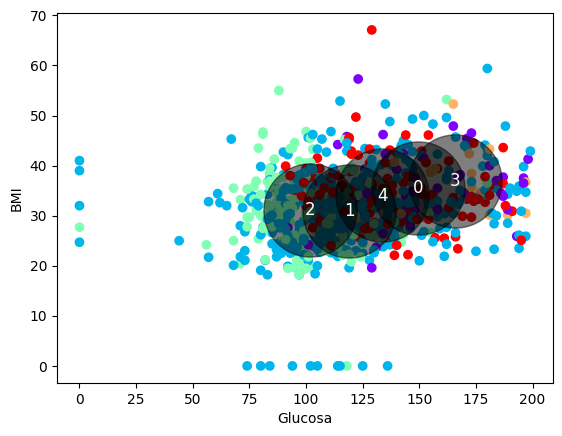

In [ ]:
XDB2['Cluster'] = ydp
display(XDB2)

#Determinar el Número de pacientes Con y Sin Diabetes por Cluster
NDiab  = XDB2.groupby('Cluster').agg({"Outcome": lambda x: (x==1).sum()})
NNoDiab = XDB2.groupby('Cluster').agg({"Outcome": lambda x: (x==0).sum()})

#Para que la decisión sea en porcentaje
NDiab2  = NDiab/(NDiab+NNoDiab); NNoDiab2 = NNoDiab/(NDiab+NNoDiab)
df2 = pd.DataFrame(np.column_stack([NDiab2, NNoDiab2]), columns=['Con Diabetes','Sin Diabetes'])
display(df2)

#Gráfica de los clusters utilizando las variables Glucose y BMI
centers = mKm.cluster_centers_
glc = np.array(XD['Glucose']); bmi = np.array(XD['BMI'])

plt.figure()
plt.scatter(glc, bmi, c=mKm.labels_, cmap='rainbow') #Todos los puntos
plt.scatter(centers[:, 1], centers[:, 5], c='black', s=4500, alpha=0.5)
plt.xlabel('Glucosa')
plt.ylabel('BMI')

#Agregar números a los centros
for i, center in enumerate(centers):
    plt.text(center[1], center[5], str(i), color='white', fontsize=12, ha='center', va='center')

plt.show()

###***Análisis de Resultados – Clustering K-Means***

El modelo K-Means con 5 clusters agrupa a los 768 pacientes en perfiles diferenciados.
El Cluster 1 es el más numeroso con 384 pacientes (50%), seguido del Cluster 2 con 177 (23%).
El Cluster 3 es el de menor tamaño con solo 18 pacientes (2.3%).

Con respecto a la probabilidad de diabetes por cluster, el Cluster 3 presenta la mayor
probabilidad de diabetes con un 66.7%, siendo el grupo de mayor riesgo clínico. Este cluster
se caracteriza por los valores más altos de Glucose (165.83) y DiabetesPedigreeFunction (0.66).
En contraste, el Cluster 2 presenta la menor probabilidad de diabetes (13.0%), agrupando
a pacientes más jóvenes (27.84 años) con glucosa más baja (101.95) y menor BMI (31.10).
El Cluster 0 presenta una probabilidad del 50%, siendo el grupo de mayor incertidumbre
que requiere atención clínica adicional para su clasificación.

8. ¿Qué pasa si aparece un nuevo paciente? Pregnancies=2, Glucose=85, BloodPressure=65, SkinThickness=29,
Insulin=94, BMI=39.6, DiabetesPedigreeFunction=0.93, Age=27

In [ ]:
nuevo_paciente = np.array([2, 85, 65, 29, 94, 39.6, 0.93, 27])

#Naive Bayes
ydc_nb = mnb.predict([nuevo_paciente])
prob_nb = mnb.predict_proba([nuevo_paciente])
print("Naive Bayes - Pronóstico:", ydc_nb)
print("Prob. Sin Diabetes:", prob_nb[0][0])
print("Prob. Con Diabetes:", prob_nb[0][1])

#Árbol de Decisión
ydc_ar = mar.predict([nuevo_paciente])
prob_ar = mar.predict_proba([nuevo_paciente])
print("Árbol de Decisión - Pronóstico:", ydc_ar)
print("Prob. Sin Diabetes:", prob_ar[0][0])
print("Prob. Con Diabetes:", prob_ar[0][1])

#K-Means
ydp_km = mKm.predict(nuevo_paciente.reshape(1, -1))
NC1 = ydp_km[0]
print("La nueva persona pertenece al cluster:", ydp_km)
print("El porcentaje de diabetes para la nueva persona es:", NDiab2.iloc[NC1])
print("El porcentaje sin diabetes para la nueva persona es:", NNoDiab2.iloc[NC1])

Naive Bayes - Pronóstico: [0]
Prob. Sin Diabetes: 0.8721705474851683
Prob. Con Diabetes: 0.12782945251483196
Árbol de Decisión - Pronóstico: [0]
Prob. Sin Diabetes: 0.8448275862068966
Prob. Con Diabetes: 0.15517241379310345
La nueva persona pertenece al cluster: [2]
El porcentaje de diabetes para la nueva persona es: Outcome    0.129944
Name: 2, dtype: float64
El porcentaje sin diabetes para la nueva persona es: Outcome    0.870056
Name: 2, dtype: float64


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


###***Análisis de Resultados – Pronóstico Nuevo Paciente***

Para el paciente con XDp=[2, 85, 65, 29, 94, 39.6, 0.93, 27], los tres modelos
convergen de forma unánime en el pronóstico de SIN DIABETES (Outcome=0):

- Naive Bayes: SIN DIABETES con probabilidad del 87.22%.
- Árbol de Decisión: SIN DIABETES con probabilidad del 84.48%. El paciente sigue
  la regla: Glucose (85) ≤ 127.50 AND Age (27) ≤ 28.50 AND BMI (39.6) ≤ 45.40,
  cayendo en el nodo puro de mayor tamaño del árbol (clase 0).
- K-Means: El paciente es asignado al Cluster 2, el grupo de menor riesgo,
  con una probabilidad de diabetes del 13.0%.

El elemento que merece mayor atención clínica es el BMI de 39.6 (obesidad clase II)
y la DiabetesPedigreeFunction de 0.93 (carga genética moderada-alta). Sin embargo,
su glucosa baja (85 mg/dL) y edad joven (27 años) son factores protectores que llevan
a los tres modelos a clasificarlo como paciente SIN diabetes. Se recomienda seguimiento
preventivo dado su perfil de riesgo metabólico y antecedentes genéticos.

###***Conclusión – Modelo Recomendado***

Tras comparar los tres modelos implementados, se recomienda el Árbol de Decisión como el modelo más adecuado para la clasificación de pacientes con diabetes en esta entidad de salud, sustentado en las siguientes razones:

Desde el punto de vista de las métricas, el árbol de decisión obtuvo la mayor exactitud (79.2%) frente a Naive Bayes (76.3%), y adicionalmente logró la especificidad más alta (91.8%), lo que significa que identifica correctamente a los pacientes sanos en 9 de cada 10 casos, reduciendo al mínimo las alarmas falsas que podrían generar costos innecesarios al sistema de salud.

Desde el criterio de negocio e interpretación, el árbol de decisión ofrece una ventaja fundamental: sus reglas son completamente transparentes y explicables para el personal médico. Un médico puede entender y validar fácilmente una regla como "si el paciente tiene glucosa mayor a 127.50 y BMI mayor a 29.95 y más de 30 años, entonces tiene diabetes", lo cual genera confianza en el modelo y facilita su adopción clínica. Naive Bayes, aunque competitivo en exactitud, opera como una caja negra estadística menos interpretable. K-Means por su parte es un modelo no supervisado orientado a segmentación, por lo que no es el más adecuado para clasificación directa de pacientes.

En conclusión, para un problema de salud donde la interpretabilidad, la confianza del equipo médico y la reducción de falsos positivos son criterios prioritarios, el Árbol de Decisión representa la mejor opción tanto técnica como estratégica.